# Multitag localization

Localize the tags of every experiment folder from their tag-to-tag distance matrices with the SFSDP solver used in `../Localization/localize.py` (`SDPwrapper` via the MATLAB Engine API).

For each experiment we run the solver on three distance matrices:
- **Ground truth**: `distances.csv` (shows the error of the solver alone),
- **SVR 775-995** and **SVR 775-955**: `dist_est_svr` from `distance_estimates.csv` (written by `ML_ranging_multitag_SVR.ipynb`), averaged over runs into an NxN matrix for each band.

**Setup.** Localization is in 2D (x, y): z is almost constant within an experiment. `N_ANCHORS` tags with known positions (from `points.csv`) are chosen per experiment as the ones spanning the largest area (max-area convex polygon); the other tags are the sensors to localize. With 4 anchors the solver fails on some experiments even with ground-truth distances, while 5 localize all of them. Every sensor-sensor and sensor-anchor distance is used. Localization error = Euclidean distance between estimated and true sensor positions.

In [9]:
import itertools
from pathlib import Path

import matlab
import matlab.engine
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

DATA_DIR = Path(".")
LOC_DIR = Path("../Localization").resolve()
EXPERIMENTS = sorted((p.parent for p in DATA_DIR.glob("*/points.csv")), key=lambda p: int(p.name))
# Method -> (band, column of distance_estimates.csv); None = ground-truth distances.csv
METHODS = {
    "Ground truth": None,
    "SVR 775-995": ("775-995", "dist_est_svr"),
    "SVR 775-955": ("775-955", "dist_est_svr"),
}
S_DIM = 2
N_ANCHORS = 6
print([p.name for p in EXPERIMENTS])

['1', '2', '3', '4', '5', '6', '7', '8', '9']


## Solver
Same parameters as `localize.py`. Columns of the location matrix are ordered sensors first, anchors last, as SFSDP expects.

In [10]:
eng = matlab.engine.start_matlab()
eng.addpath(str(LOC_DIR), nargout=0)
eng.addpath(str(LOC_DIR / "SFSDP" / "SFSDP"), nargout=0)
eng.addpath(str(LOC_DIR / "SFSDP" / "SFSDP" / "subprograms"), nargout=0)


def pick_anchors(pts, n=N_ANCHORS):
    # The n tags whose convex hull has the largest area (indices into pts, 0-based).
    return np.array(max(itertools.combinations(range(len(pts)), n), key=lambda s: ConvexHull(pts[list(s)]).volume))


def load_distances(exp, method):
    # NxN tag distance matrix (tag number = index + 1); estimates are averaged over runs, unmeasured links are 0.
    D_gt = np.loadtxt(exp / "distances.csv", delimiter=",", ndmin=2)
    if METHODS[method] is None:
        return D_gt
    band, col = METHODS[method]
    est = pd.read_csv(exp / "distance_estimates.csv")
    est = est[est["band (MHz)"] == band].groupby(["tagA_num", "tagB_num"])[col].mean()
    D = np.zeros_like(D_gt)
    for (a, b), d in est.items():
        D[a - 1, b - 1] = D[b - 1, a - 1] = d
    return D


def localize(D, pts, anchors):
    # D: NxN tag distance matrix, pts: N x S_DIM true positions. Returns errors (m) and estimates for the sensors.
    sensors = np.setdiff1d(np.arange(len(pts)), anchors)
    order = np.concatenate([sensors, anchors])
    D, true_loc = D[np.ix_(order, order)], pts[order].T
    ns, n = len(sensors), len(order)

    # noOfSensors x n, sensor-sensor block upper triangular (i < j)
    meas = np.zeros((ns, n))
    for i in range(ns):
        meas[i, i + 1:] = D[i, i + 1:]

    pars = {
        "sDim": float(S_DIM),
        "noOfSensors": float(ns),
        "noOfAnchors": float(len(anchors)),
        "noisyFac": 0.0,
        "edgeAlgo": "all",
        "SDPsolver": "sedumi",
        "localMethodSW": 1.0,
        "show_plots": 0.0,
        "verbose": 0.0,
    }
    _, est, _, _ = eng.SDPwrapper(pars, matlab.double(meas.tolist()), matlab.double(true_loc.tolist()), nargout=4)
    est = np.array(est)[:, :ns].T
    return np.linalg.norm(est - pts[sensors], axis=1), sensors, est

## Localize every experiment

In [11]:
rows, results = [], {}
for exp in EXPERIMENTS:
    pts = pd.read_csv(exp / "points.csv")[["x", "y", "z"]].to_numpy()[:, :S_DIM]
    anchors = pick_anchors(pts)
    for method in METHODS:
        D = load_distances(exp, method)
        err, sensors, est = localize(D, pts, anchors)
        results[exp.name, method] = (pts, anchors, sensors, est, err)
        rows += [{"experiment": int(exp.name), "method": method, "tag": s + 1, "error (cm)": e * 100}
                 for s, e in zip(sensors, err)]
    print(f"experiment {exp.name}: anchors = tags {sorted((anchors + 1).tolist())}")
errors = pd.DataFrame(rows)

experiment 1: anchors = tags [3, 5, 6, 7, 10, 11]
experiment 2: anchors = tags [2, 5, 6, 7, 10, 11]
experiment 3: anchors = tags [1, 2, 7, 10, 11, 12]
experiment 4: anchors = tags [1, 2, 7, 10, 11, 12]
experiment 5: anchors = tags [1, 5, 7, 8, 10, 11]
experiment 6: anchors = tags [1, 4, 7, 8, 10, 11]
experiment 7: anchors = tags [2, 4, 6, 7, 8, 11]
experiment 8: anchors = tags [1, 2, 4, 6, 7, 11]
experiment 9: anchors = tags [2, 4, 5, 6, 7, 11]


## Localization error per experiment (cm)

In [12]:
def summary(e):
    return pd.Series({"mean": e.mean(), "median": e.median(), "p90": e.quantile(0.9), "max": e.max()})


per_exp = errors.groupby(["experiment", "method"], sort=False)["error (cm)"].apply(summary).unstack().round(1)
overall = errors.groupby("method", sort=False)["error (cm)"].apply(summary).unstack().round(1)
overall.index = pd.MultiIndex.from_product([["All"], overall.index])
pd.concat([per_exp, overall])

mean  median   p90    max
    method                                 
1   Ground truth   0.1     0.0   0.2    0.3
    SVR 775-995   30.6    11.1  77.0  139.8
    SVR 775-955   32.0    14.6  76.1  135.2
2   Ground truth   3.7     3.7   6.2    6.5
    SVR 775-995   13.6    15.3  18.8   19.9
    SVR 775-955   19.2    20.6  24.3   26.8
3   Ground truth   0.0     0.0   0.0    0.0
    SVR 775-995   15.9    15.2  24.4   27.3
    SVR 775-955   12.0    11.0  20.6   25.7
4   Ground truth   0.1     0.1   0.2    0.2
    SVR 775-995   14.9    15.3  21.8   27.0
    SVR 775-955   24.3    18.5  42.5   61.6
5   Ground truth   0.0     0.0   0.0    0.1
    SVR 775-995   23.9     7.7  60.5  111.0
    SVR 775-955   28.5    12.4  65.6  111.1
6   Ground truth   0.7     0.7   1.3    1.5
    SVR 775-995   10.7     6.1  22.2   33.2
    SVR 775-955   10.6     5.8  22.7   37.2
7   Ground truth   0.0     0.0   0.0    0.0
    SVR 775-995   24.7    10.6  55.8   92.4
    SVR 775-955   12.9     6.8  28.7   45.3
8   Ground truth   0.0     0.0   0.1    0.1
    SVR 775-995   12.7     9.1  22.9   29.5
    SVR 775-955   14.0     9.0  25.6   35.6
9   Ground truth   0.0     0.0   0.0    0.0
    SVR 775-995   11.0     9.9  17.5   21.4
    SVR 775-955   15.9    10.1  34.7   53.0
All Ground truth   0.5     0.0   1.4    6.5
    SVR 775-995   17.6    10.4  27.2  139.8
    SVR 775-955   18.8    12.3  36.7  135.2

In [13]:
# Mean error per experiment, one column per method (cm)
errors.pivot_table(index="experiment", columns="method", values="error (cm)", aggfunc="mean", sort=False).round(1)

method,Ground truth,SVR 775-995,SVR 775-955
experiment,,,
1,0.1,30.6,32.0
2,3.7,13.6,19.2
3,0.0,15.9,12.0
4,0.1,14.9,24.3
5,0.0,23.9,28.5
6,0.7,10.7,10.6
7,0.0,24.7,12.9
8,0.0,12.7,14.0
9,0.0,11.0,15.9


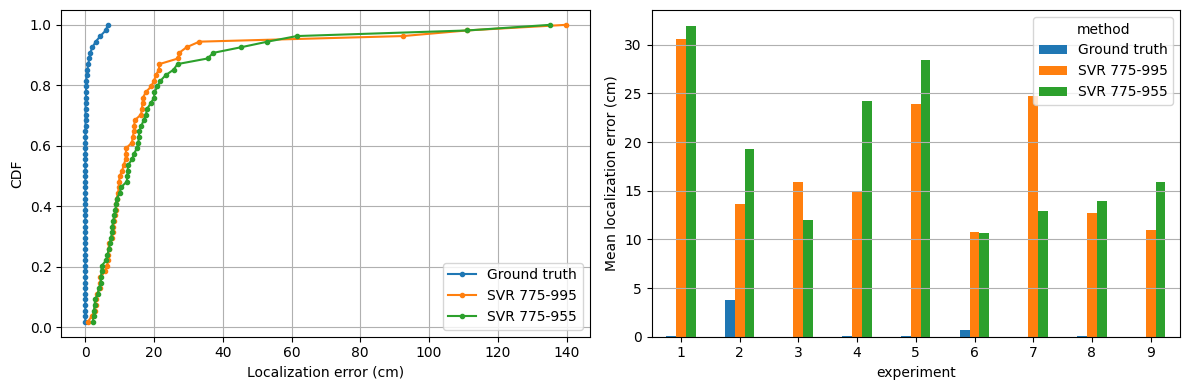

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
for method in METHODS:
    e = np.sort(errors.loc[errors.method == method, "error (cm)"])
    axs[0].plot(e, np.arange(1, len(e) + 1) / len(e), ".-", label=method)
axs[0].set_xlabel("Localization error (cm)"); axs[0].set_ylabel("CDF"); axs[0].grid(); axs[0].legend()

means = errors.pivot_table(index="experiment", columns="method", values="error (cm)", aggfunc="mean", sort=False)
means.plot.bar(ax=axs[1], rot=0)
axs[1].set_ylabel("Mean localization error (cm)"); axs[1].grid(axis="y")
plt.tight_layout(); plt.show()

## Estimated vs true positions

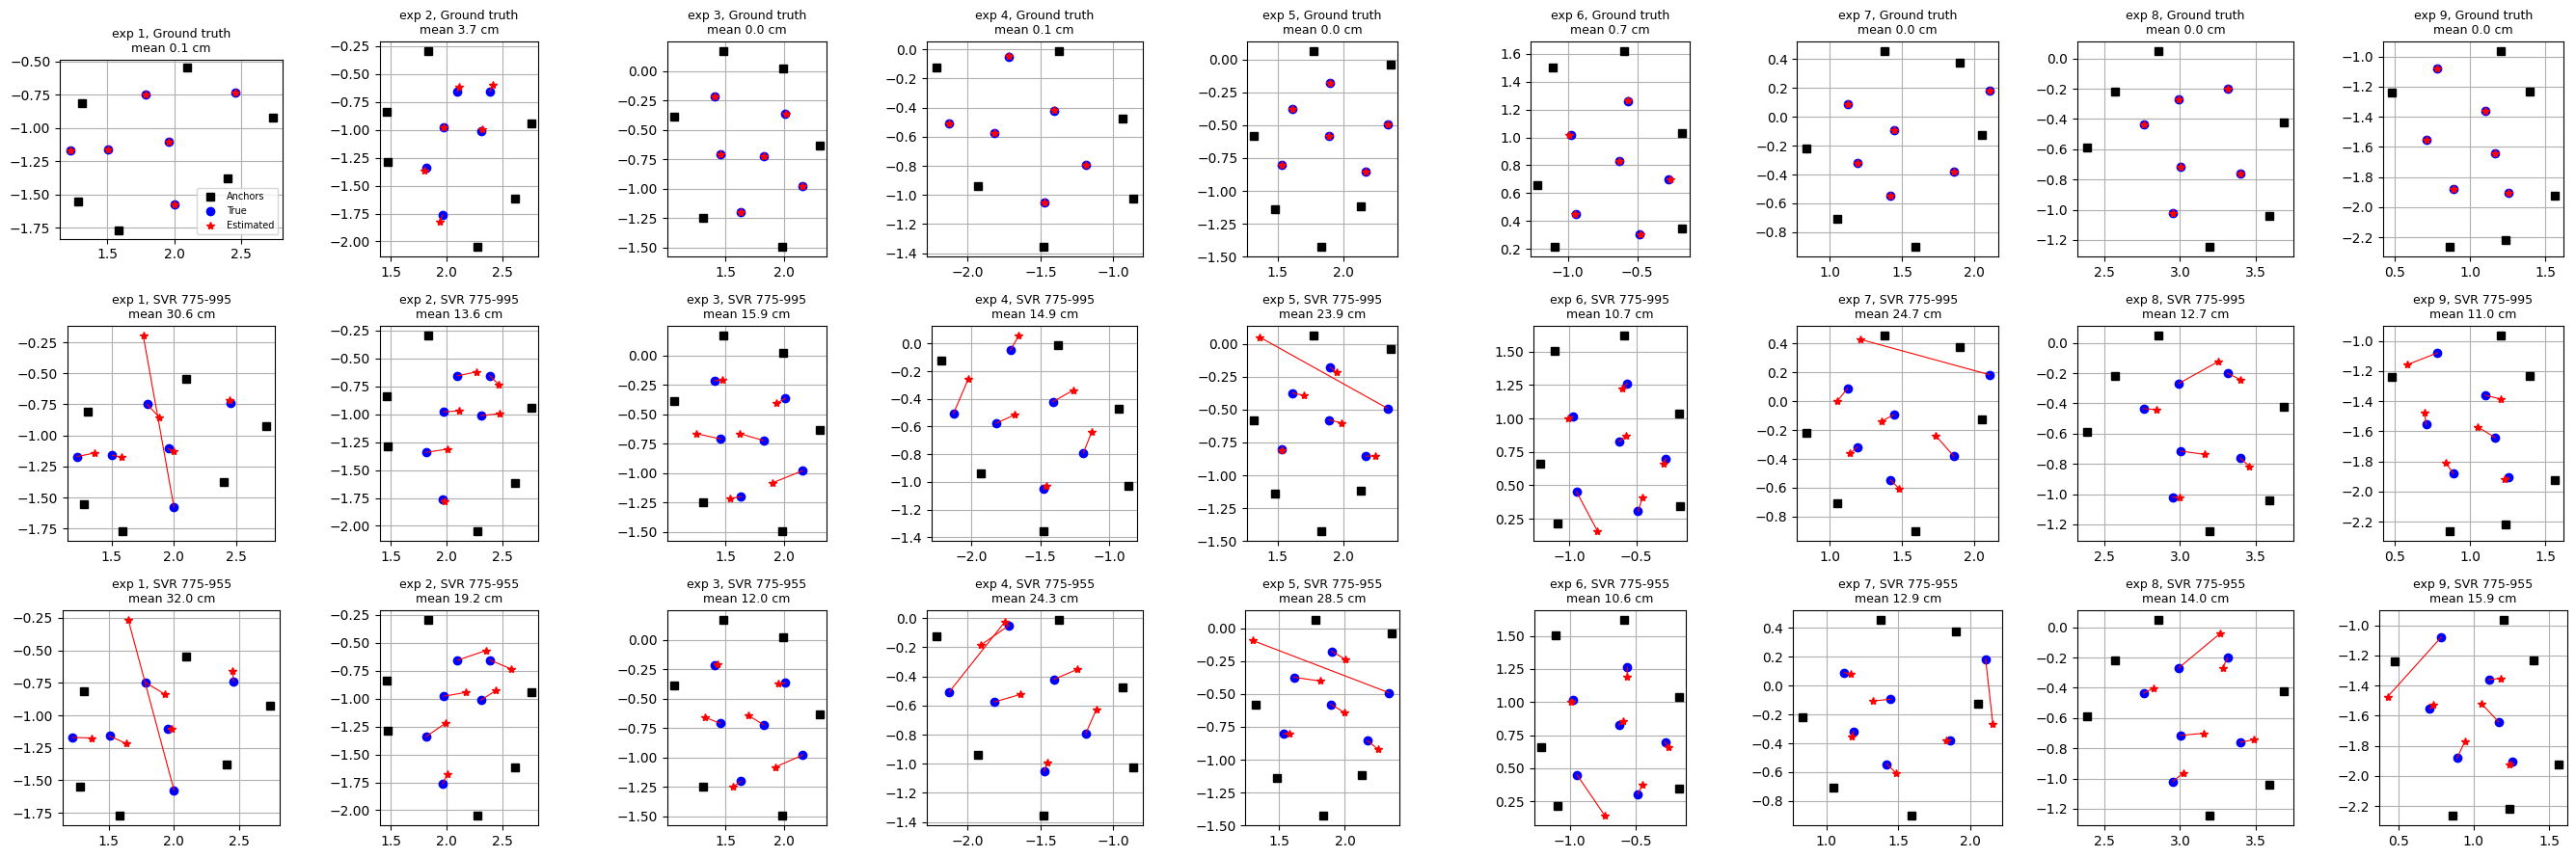

In [15]:
fig, axs = plt.subplots(len(METHODS), len(EXPERIMENTS), figsize=(3 * len(EXPERIMENTS), 3 * len(METHODS)), squeeze=False)
for c, exp in enumerate(EXPERIMENTS):
    for r, method in enumerate(METHODS):
        pts, anchors, sensors, est, err = results[exp.name, method]
        ax = axs[r, c]
        ax.plot(*pts[anchors].T, "ks", label="Anchors")
        ax.plot(*pts[sensors].T, "bo", label="True")
        ax.plot(*est.T, "r*", label="Estimated")
        for t, e in zip(pts[sensors], est):
            ax.plot([t[0], e[0]], [t[1], e[1]], "r-", lw=0.8)
        ax.set_aspect("equal"); ax.grid()
        ax.set_title(f"exp {exp.name}, {method}\nmean {err.mean() * 100:.1f} cm", fontsize=9)
axs[0, 0].legend(fontsize=7)
plt.tight_layout(); plt.show()

In [16]:
eng.quit()